# Neural Network for predicting utilization

Aktuelles Problem warum NN meiner Meinung nach nicht richtig lernt: Wetterdaten für 2021 fehlen, dadurch ist der gesamte Datensatz nicht vollständig

#### Import all important Librarys

In [182]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os
os.environ["KERAS_BACKEND"] = "torch"
import keras
from keras import Sequential # sequential model: https://keras.io/guides/sequential_model/
from keras.layers import Dense, Dropout
from keras.regularizers import l2

# supress versioning warnings of keras
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

#### Read in the Data

In [183]:
site1 = pd.read_csv("FINAL1.csv")
site2 = pd.read_csv("FINAL2.csv")

In [192]:
site1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29760 entries, 0 to 29759
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                29760 non-null  int64  
 1   hour                      29760 non-null  int64  
 2   weekday                   29760 non-null  int64  
 3   dayOfMonth                29760 non-null  int64  
 4   month                     29760 non-null  int64  
 5   year                      29760 non-null  int64  
 6   total minutes of parking  29760 non-null  float64
 7   temperature               23594 non-null  float64
 8   cloud_cover               23594 non-null  float64
 9   pressure                  23594 non-null  float64
 10  windspeed                 23594 non-null  float64
 11  precipitation             23594 non-null  float64
 12  felt_temperature          23594 non-null  float64
 13  is_holiday                29760 non-null  int64  
 14  covid 

In [184]:
site1["total minutes of parking"].describe()

count    29760.000000
mean       437.645967
std        883.152735
min          0.000000
25%          0.000000
50%          5.166667
75%        275.558333
max       3120.000000
Name: total minutes of parking, dtype: float64

In [185]:
site2["total minutes of parking"].describe()

count    29760.000000
mean       437.645967
std        883.152735
min          0.000000
25%          0.000000
50%          5.166667
75%        275.558333
max       3120.000000
Name: total minutes of parking, dtype: float64

The target variable is the **total occupied charging minutes per hour**.

We can see that the maximum possible utilization per hour is 3120 minutes which are equivalent to 3120 minutes / 60 minutes = 52 stations.

---

The goal of this prediction task is not only to achieve high statistical accuracy, but to evaluate whether the model is suitable for **operational and strategic decision-making** by a charging hub operator.

More specifically, we want to verify:

1. **Operational Accuracy**  
   How many charging minutes per hour does the model misestimate on average?
   → This determines whether short-term planning (e.g. load management) is feasible.

2. **Risk of Large Errors**  
   Does the model occasionally make very large mistakes?
   → Large underestimations during peak hours could lead to grid overload or customer dissatisfaction.

3. **Relative Accuracy Compared to Site Capacity**  
   How large are the prediction errors relative to the maximum possible utilization?
   → This allows interpretation in percentage terms and comparison across sites.

4. **Explanatory Power**  
   Does the model capture the structural patterns of utilization over time?
   → Important to assess whether predictions are systematic or mostly noise.

---

## NN for Site 1

First we build up a NN for Site 1 with random hyperparameters, to see if a NN is useful for this task

#### Create the target and the features

In [ ]:
y = site1["total minutes of parking"]
X = site1.drop(columns=["total minutes of parking"])

#### Split the data

In [187]:
from sklearn.model_selection import train_test_split

X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, random_state=42)

- X_train, y_train → 60%: Training set

- X_val, y_val → 20%: Validation set

- X_test, y_test → 20%: Test set

#### Scale the data

In [188]:
from sklearn.preprocessing import StandardScaler
norm = StandardScaler()
norm.fit(X_train)

X_norm_train = norm.transform(X_train)
X_norm_val = norm.transform(X_val)
X_norm_test = norm.transform(X_test)

#### Build the NN
We use a common neural network architecture from the lecture, but we also include the Keras L2 regularizer to reduce overfitting and improve the model’s generalization to new data.

In [189]:
classifier = Sequential()

classifier.add(Dense(units=64,
                     activation='relu',
                     input_shape=(14,)))

classifier.add(Dense(units=64, 
                     activation='relu', 
                     kernel_regularizer=l2(0.001)))
classifier.add(Dropout(0.05))

classifier.add(Dense(units=64, 
                     activation='relu', 
                     kernel_regularizer=l2(0.001)))
classifier.add(Dropout(0.05))

classifier.add(Dense(units=64, 
                     activation='relu', 
                     kernel_regularizer=l2(0.001)))
classifier.add(Dropout(0.05))

classifier.add(Dense(1, activation='relu'))

classifier.summary()


Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_81 (Dense)                │ (None, 64)             │           960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_82 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_48 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_83 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_49 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_84 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_50 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_85 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,505 (52.75 KB)

 Trainable params: 13,505 (52.75 KB)

 Non-trainable params: 0 (0.00 B)

#### Compile the NN

In [190]:
classifier.compile(loss='mse',
             optimizer="adam",
             metrics=["mae", "mse"])

#### Train the NN

In [191]:
history = classifier.fit(X_norm_train, y_train,
                            validation_data=(X_norm_val, y_val),
                            epochs=100,
                            batch_size=50)

Epoch 1/100
358/358 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - loss: 845040.0625 - mae: 527.7678 - mse: 845039.9375 - val_loss: 793254.8125 - val_mae: 608.5637 - val_mse: 793254.4375
Epoch 2/100
358/358 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - loss: 776617.1875 - mae: 605.6911 - mse: 776616.8125 - val_loss: 792633.8750 - val_mae: 631.0852 - val_mse: 792633.4375
Epoch 3/100
358/358 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - loss: 777153.5625 - mae: 606.3261 - mse: 777152.9375 - val_loss: 792460.3750 - val_mae: 623.3352 - val_mse: 792459.8750
Epoch 4/100
358/358 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - loss: 777342.8750 - mae: 606.9545 - mse: 777342.6250 - val_loss: 792788.1875 - val_mae: 614.0051 - val_mse: 792787.8750
Epoch 5/100
231/358 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 761949.8125 - mae: 598.9434 - mse: 761949.3750

KeyboardInterrupt: 

#### Results of the NN

In [ ]:
history_df = pd.DataFrame(history.history)
history_df

,loss,mae,mse,val_loss,val_mae,val_mse
0,809265.5000,566.725830,809265.2500,792472.9375,621.885925,792472.2500
1,776165.5625,608.106445,776165.2500,795938.1250,592.183105,795937.7500
2,777778.5625,605.971069,777778.3125,794088.1875,602.048035,794087.7500
3,776504.9375,606.130798,776504.5625,793282.5625,608.300415,793282.0625
4,777371.5000,606.461548,777371.1250,793975.3125,602.809326,793974.6250


In [ ]:
root_metrics_df = history_df[["mse", "val_mse"]].apply(np.sqrt)
root_metrics_df.rename({"mse":"rmse", "val_mse":"val_rmse"}, axis=1, inplace=True)
root_metrics_df

,rmse,val_rmse
0,899.591713,890.209105
1,881.002412,892.153434
2,881.917407,891.116014
3,881.194963,890.663832
4,881.686523,891.052538


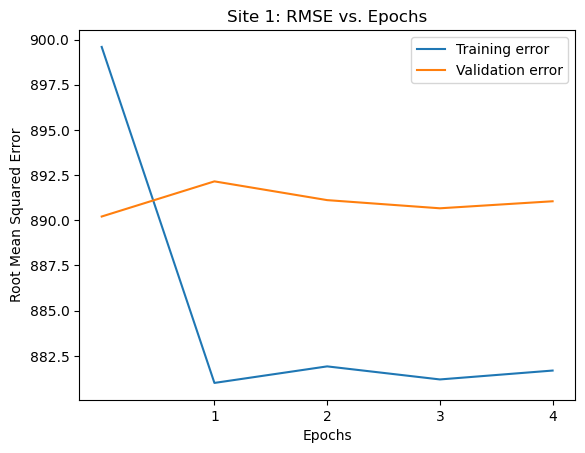

In [ ]:
plt.figure(figsize=(14,6), dpi=100)

plt.plot(root_metrics_df["rmse"], label = 'Training error')
plt.plot(root_metrics_df["val_rmse"], label = 'Validation error')

plt.xlabel("Epochs")
plt.ylabel("Root Mean Squared Error")

plt.xticks(range(1,101))
plt.legend()
plt.title("Site 1: RMSE vs. Epochs")

plt.show()

### TDB: Hier noch Ergebnis etc dazuschreiben

The NN is working so we set up another one for Site 2

## NN for Site 2

We build up the NN for Site 2 similar to the NN from Site 1

In [ ]:
y = site2["total minutes of parking"]
X = site2.drop(columns=["total minutes of parking"])

X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, random_state=42)

norm = StandardScaler()
norm.fit(X_train)

X_norm_train = norm.transform(X_train)
X_norm_val = norm.transform(X_val)
X_norm_test = norm.transform(X_test)

classifier = Sequential()

classifier.add(Dense(units=64,
                     activation='relu',
                     input_shape=(14,)))

classifier.add(Dense(units=64, 
                     activation='relu', 
                     kernel_regularizer=l2(0.001)))
classifier.add(Dropout(0.05))

classifier.add(Dense(units=64, 
                     activation='relu', 
                     kernel_regularizer=l2(0.001)))
classifier.add(Dropout(0.05))

classifier.add(Dense(units=64, 
                     activation='relu', 
                     kernel_regularizer=l2(0.001)))
classifier.add(Dropout(0.05))

classifier.add(Dense(1, activation='relu'))

classifier.summary()

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_66 (Dense)                │ (None, 100)            │         1,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_67 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_39 (Dropout)            │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_68 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_40 (Dropout)            │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_69 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_41 (Dropout)            │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_70 (Dense)                │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,901 (124.61 KB)

 Trainable params: 31,901 (124.61 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
classifier.compile(loss='mse',
             optimizer="adam",
             metrics=["mae", "mse"])

In [ ]:
history = classifier.fit(X_norm_train, y_train,
                            validation_data=(X_norm_val, y_val),
                            epochs=100,
                            batch_size=50)

Epoch 1/5
715/715 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step - loss: 803850.6250 - mae: 576.8104 - mse: 803850.1250 - val_loss: 793412.1250 - val_mae: 607.1293 - val_mse: 793411.9375
Epoch 2/5
715/715 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - loss: 776779.3125 - mae: 607.2201 - mse: 776778.7500 - val_loss: 794401.5625 - val_mae: 600.0728 - val_mse: 794401.1250
Epoch 3/5
715/715 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - loss: 777167.1250 - mae: 604.7224 - mse: 777166.8125 - val_loss: 792619.4375 - val_mae: 630.7714 - val_mse: 792618.8125
Epoch 4/5
715/715 ━━━━━━━━━━━━━━━━━━━━ 14s 19ms/step - loss: 776890.4375 - mae: 608.0202 - mse: 776890.0000 - val_loss: 793659.6875 - val_mae: 605.1069 - val_mse: 793659.1875
Epoch 5/5
715/715 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - loss: 777164.1875 - mae: 606.5493 - mse: 777163.9375 - val_loss: 794715.9375 - val_mae: 598.2529 - val_mse: 794715.4375


In [ ]:
history_df = pd.DataFrame(history.history)
history_df

,loss,mae,mse,val_loss,val_mae,val_mse
0,803850.6250,576.810425,803850.1250,793412.1250,607.129333,793411.9375
1,776779.3125,607.220093,776778.7500,794401.5625,600.072815,794401.1250
2,777167.1250,604.722412,777166.8125,792619.4375,630.771362,792618.8125
3,776890.4375,608.020203,776890.0000,793659.6875,605.106934,793659.1875
4,777164.1875,606.549255,777163.9375,794715.9375,598.252869,794715.4375


In [ ]:
root_metrics_df = history_df[["mse", "val_mse"]].apply(np.sqrt)
root_metrics_df.rename({"mse":"rmse", "val_mse":"val_rmse"}, axis=1, inplace=True)
root_metrics_df

,rmse,val_rmse
0,896.576893,890.736739
1,881.350526,891.291829
2,881.570651,890.291420
3,881.413637,890.875517
4,881.569020,891.468136


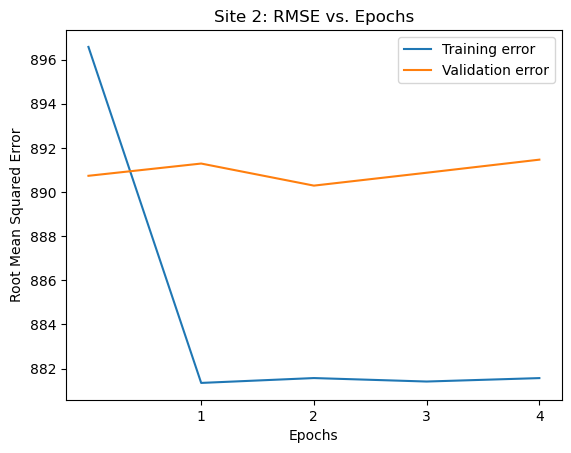

In [ ]:
plt.figure(figsize=(14,6), dpi=100)

plt.plot(root_metrics_df["rmse"], label = 'Training error')
plt.plot(root_metrics_df["val_rmse"], label = 'Validation error')

plt.xlabel("Epochs")
plt.ylabel("Root Mean Squared Error")

plt.xticks(range(1,101))
plt.legend()
plt.title("Site 2: RMSE vs. Epochs")

plt.show()